In [ ]:
import numpy as numpy
import pandas as pandas
import matplotlib.pyplot as pyplot
import seaborn as sns

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression


In [ ]:
df = pd.read_csv("fruit_price_prediction.csv")

In [ ]:
df.head()

df.shape

df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Fruit           300 non-null    str    
 1   Season          300 non-null    str    
 2   Weight_g        288 non-null    float64
 3   Quality         290 non-null    str    
 4   Demand          300 non-null    int64  
 5   Price_Category  300 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 14.2 KB


,Weight_g,Demand
count,288.000000,300.000000
mean,224.069444,60.416667
std,92.648611,23.308238
min,82.000000,20.000000
25%,154.000000,39.000000
50%,221.500000,59.000000
75%,288.250000,81.250000
max,676.000000,100.000000


In [ ]:
df.isnull().sum()

Fruit              0
Season             0
Weight_g          12
Quality           10
Demand             0
Price_Category     0
dtype: int64

In [ ]:
df["Weight_g"].fillna(df["Weight_g"].median(), inplace=True)

df["Quality"].fillna(df["Quality"].mode()[0], inplace=True)

/tmp/ipykernel_7526/2566776124.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Weight_g"].fillna(df["Weight_g"].median(), inplace=True)
/tmp/ipykernel_7526/2566776124.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method ne

0      Premium
1      Average
2      Premium
3      Average
4      Average
        ...   
295    Premium
296    Average
297    Average
298    Premium
299    Premium
Name: Quality, Length: 300, dtype: str

In [ ]:
df.duplicated().sum()

np.int64(0)

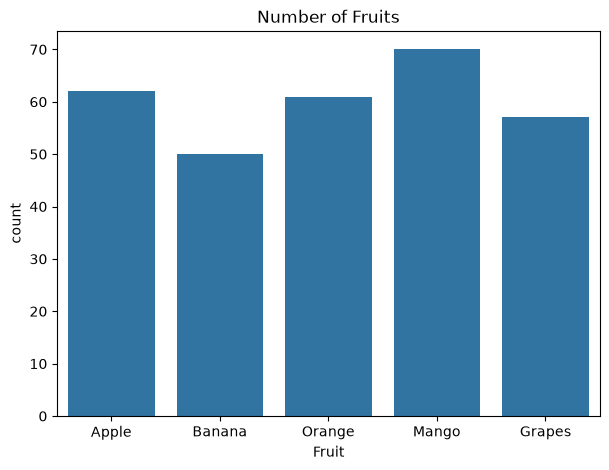

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(x="Fruit", data=df)

plt.title("Number of Fruits")

plt.show()


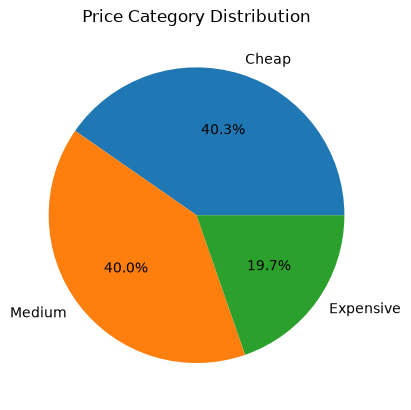

In [ ]:
df["Price_Category"].value_counts().plot(
kind="pie",
autopct="%1.1f%%"
)

plt.title("Price Category Distribution")

plt.ylabel("")

plt.show()


In [ ]:
encoder = LabelEncoder()

df["Fruit"] = encoder.fit_transform(df["Fruit"])

df["Season"] = encoder.fit_transform(df["Season"])

df["Quality"] = encoder.fit_transform(df["Quality"])

df["Price_Category"] = encoder.fit_transform(df["Price_Category"])


In [ ]:
X = df.drop("Price_Category", axis=1)

y = df["Price_Category"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)